In [128]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# auth.authenticate_user()

# Read Data

In [129]:
client = bigquery.Client(project="alterdata-rekrutacja-28")

query_cost_revenue = """ SELECT * FROM `alterdata-rekrutacja-scientist.marketing_data.cost_revenue` """
query_promotions = """ SELECT * FROM `alterdata-rekrutacja-scientist.marketing_data.promotions` """
cost_revenue_df = client.query(query_cost_revenue).to_dataframe()
promotions_df = client.query(query_promotions).to_dataframe()
cost_revenue_df.head()

,week,geo,impression_tiktok,impression_tv,impression_outdoor1,impression_google,impression_facebook,impression_outdoor2,impression_organic,market_share,cost_tiktok,cost_tv,cost_outdoor1,cost_google,cost_facebook,cost_outdoor2,conversions,revenue,population
0,2022-10-03,Geo0,495955,323000,24000,895616,241546,<NA>,156720,0.044674,3636.700700000,3113.394800000,180.460000000,6979.392600000,1882.105100000,387.499424,2193336.500000000,43971.176684130,136670.940000000
1,2022-09-26,Geo0,316706,408000,168000,944990,384225,<NA>,304060,0.058172,2322.317400000,3935.714600000,1250.409200000,7364.156700000,2993.847200000,2254.286274,2972293.800000000,59492.778796164,136670.940000000
2,2023-09-11,Geo0,124229,229000,99000,865630,412929,<NA>,152068,0.046063,910.936900000,2210.368000000,736.687000000,6745.716300000,3217.506300000,1270.646476,2624217.500000000,52411.097592705,136670.940000000
3,2022-03-14,Geo0,306297,341000,200000,647233,525200,<NA>,243823,0.052139,2245.991000000,3288.682000000,1483.368700000,5043.783700000,4092.312000000,2764.278692,2489067.200000000,49671.297360954,136670.940000000
4,2022-08-22,Geo0,287110,575000,175000,274969,429373,<NA>,382009,0.057232,2105.298300000,5546.928700000,1303.451000000,2142.789600000,3345.636500000,2161.070642,2840257.200000000,56950.417475266,136670.940000000


In [130]:
promotions_df.head()

,week,geo,promo_description
0,2021-12-13,Geo15,-20% rabatu na całe zamówienie po przekroczeni...
1,2022-11-21,Geo16,-20% rabatu na całe zamówienie po przekroczeni...
2,2023-11-06,Geo31,-20% rabatu na całe zamówienie po przekroczeni...
3,2021-02-08,Geo34,-20% rabatu na całe zamówienie po przekroczeni...
4,2021-06-21,Geo4,-20% rabatu na całe zamówienie po przekroczeni...


# EDA

In [131]:
cost_revenue_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6200 entries, 0 to 6199
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   week                 6200 non-null   dbdate 
 1   geo                  6200 non-null   object 
 2   impression_tiktok    6200 non-null   Int64  
 3   impression_tv        5874 non-null   Int64  
 4   impression_outdoor1  6200 non-null   Int64  
 5   impression_google    6200 non-null   Int64  
 6   impression_facebook  6200 non-null   Int64  
 7   impression_outdoor2  0 non-null      Int64  
 8   impression_organic   6200 non-null   Int64  
 9   market_share         6200 non-null   float64
 10  cost_tiktok          6200 non-null   object 
 11  cost_tv              6200 non-null   object 
 12  cost_outdoor1        6200 non-null   object 
 13  cost_google          6200 non-null   object 
 14  cost_facebook        6200 non-null   object 
 15  cost_outdoor2        6200 non-null   f

In [132]:
promotions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3299 entries, 0 to 3298
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   week               3299 non-null   dbdate
 1   geo                3299 non-null   object
 2   promo_description  3299 non-null   object
dtypes: dbdate(1), object(2)
memory usage: 77.4+ KB


In [133]:
# add promotions and promotions flag to cost_revenue df
promotions_df["promo"] = 1
cost_revenue_df = pd.merge(cost_revenue_df, promotions_df, on=["geo", "week"], how="left")
cost_revenue_df["promo"] = cost_revenue_df["promo"].fillna(0)

In [134]:
# change data type to numeric
for col in ["cost_tiktok", "cost_tv", "cost_outdoor1", "cost_google", "cost_facebook", "conversions", "revenue", "population"]:
    cost_revenue_df[col] = pd.to_numeric(cost_revenue_df[col], errors="coerce")

In [135]:
# global sanity ckeck
channels = {
    "tv": ("cost_tv", "impression_tv"),
    "outdoor1": ("cost_outdoor1", "impression_outdoor1"),
    "outdoor2": ("cost_outdoor2", "impression_outdoor2"),
    "google": ("cost_google", "impression_google"),
    "meta": ("cost_facebook", "impression_facebook"),
    "tiktok": ("cost_tiktok", "impression_tiktok"),
}
sanity_check = {}

for channel, (cost_col, imp_col) in channels.items():
    mask = (cost_revenue_df[cost_col] == 0) & (cost_revenue_df[imp_col] > 0)
    sanity_check[channel] = mask.sum()

pd.Series(sanity_check, name="cases_cost_0_impression_gt_0")

,cases_cost_0_impression_gt_0
tv,0
outdoor1,0
outdoor2,0
google,0
meta,0
tiktok,0


## Handle Missing Value
Missing values ​​in the columns impression_tv and impression_outdoor_2 will be filled in based on the ratio in each region, i.e. impressions per PLN 1. The impression_outdoor_1 column will be used to fill the impression_outdoor_2 column.

In [136]:
cost_revenue_df.describe()

,impression_tiktok,impression_tv,impression_outdoor1,impression_google,impression_facebook,impression_outdoor2,impression_organic,market_share,cost_tiktok,cost_tv,cost_outdoor1,cost_google,cost_facebook,cost_outdoor2,conversions,revenue,population,promo
count,6200.0,5874.0,6200.0,6200.0,6200.0,0.0,6200.0,6200.000000,6200.000000,6200.000000,6200.000000,6200.000000,6200.000000,6200.000000,6.200000e+03,6200.000000,6200.000000,6200.000000
mean,885854.729032,518135.682669,261643.870968,1807384.852903,978975.768871,<NA>,533079.585323,0.051430,6495.727472,5015.920660,1944.260233,14084.661852,7628.092645,3570.458824,1.056983e+07,211411.187201,542418.832750,0.532097
std,819983.122866,620071.852125,556307.221833,1305215.558778,913499.318768,<NA>,696349.328102,0.019060,6012.709228,5985.940739,4133.877448,10171.336645,7117.905927,7663.839075,6.083582e+06,121688.348393,242839.845445,0.499009
min,0.0,0.0,0.0,0.0,0.0,<NA>,0.0,0.005675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.840312e+05,9742.282233,136670.940000,0.000000
25%,253368.75,0.0,0.0,808356.5,265916.75,<NA>,0.0,0.038792,1857.882850,0.000000,0.000000,6299.393250,2071.999900,0.000000,5.718118e+06,114323.174381,335176.345000,0.000000
50%,679840.5,308500.0,0.0,1506463.5,741981.0,<NA>,270682.0,0.050229,4985.082000,2984.910850,0.000000,11739.630000,5781.450450,0.000000,9.705633e+06,193969.173224,560478.825000,1.000000
75%,1325314.75,799000.0,256250.0,2566897.5,1474323.25,<NA>,800399.75,0.062442,9718.165750,7783.443250,1906.635875,20003.423750,11487.796750,3472.400088,1.439251e+07,287918.213647,736033.810000,1.000000
max,5192032.0,4398000.0,5610000.0,7635147.0,6975542.0,<NA>,5801781.0,0.167090,38071.730000,42397.700000,41688.645000,59499.484000,54352.810000,73356.957366,3.671269e+07,739823.338940,994048.940000,1.000000


In [137]:
# check if the missing data is related only to some region
missing_by_geo = (
    cost_revenue_df.groupby("geo")
      .apply(lambda x: x.isnull().mean())
)

missing_by_geo[["impression_tv", "impression_outdoor2"]]

/tmp/ipython-input-1344883995.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean())


,impression_tv,impression_outdoor2
geo,,
Geo0,0.038710,1.0
Geo1,0.051613,1.0
Geo10,0.083871,1.0
Geo11,0.096774,1.0
Geo12,0.032258,1.0
Geo13,0.070968,1.0
Geo14,0.038710,1.0
Geo15,0.032258,1.0
Geo16,0.025806,1.0


In [138]:
cost_revenue_df[cost_revenue_df["impression_tv"].isnull()].head(5)

,week,geo,impression_tiktok,impression_tv,impression_outdoor1,impression_google,impression_facebook,impression_outdoor2,impression_organic,market_share,...,cost_tv,cost_outdoor1,cost_google,cost_facebook,cost_outdoor2,conversions,revenue,population,promo_description,promo
18,2022-07-04,Geo0,566751,<NA>,149000,380696,379788,<NA>,161962,0.073185,...,0.0000,1107.066500,2966.7034,2959.27440,2359.344676,3017796.8,60265.761214,136670.94,Wszystkie produkty z poprzedniego sezonu -40%.,1.0
35,2023-11-06,Geo0,176909,<NA>,235000,546091,305829,<NA>,131601,0.037811,...,1150.3629,1743.421300,4255.6000,2382.99240,2704.800929,2062280.5,41311.380250,136670.94,NaN,0.0
40,2023-03-27,Geo0,75067,<NA>,1000,492758,30509,<NA>,74603,0.071866,...,2680.2144,7.274875,3839.9846,237.72343,10.761971,2713922.2,54572.511040,136670.94,NaN,0.0
41,2022-10-17,Geo0,185487,<NA>,366000,984345,738102,<NA>,441399,0.029491,...,2022.5278,2722.282000,7670.8433,5751.22560,4695.346823,1778753.1,35654.212955,136670.94,NaN,0.0
71,2024-01-01,Geo1,897814,<NA>,448000,891343,307507,<NA>,575692,0.051260,...,3506.3230,3332.256800,6946.0940,2396.06710,5788.918810,3207906.5,64220.581524,199816.90,Darmowa dostawa na wszystkie zamówienia przez ...,1.0


In [139]:
# Insert 0 impression into missing data where cost is 0
cost_revenue_df.loc[
    (cost_revenue_df["cost_tv"] == 0) & (cost_revenue_df["impression_tv"].isna()),
    ["geo", "week", "cost_tv", "impression_tv"]
].shape[0]

cost_revenue_df.loc[cost_revenue_df["cost_tv"] == 0, "impression_tv"] = 0

cost_revenue_df.loc[
    (cost_revenue_df["cost_outdoor2"] == 0) & (cost_revenue_df["impression_outdoor2"].isna()),
    ["geo", "week", "cost_outdoor2", "impression_outdoor2"]
].shape[0]

cost_revenue_df.loc[cost_revenue_df["cost_outdoor2"] == 0, "impression_outdoor2"] = 0

In [140]:
# fill in missing values ​​using ratio in the impression_tv column
tv_ratio = (
    cost_revenue_df
    .loc[cost_revenue_df["impression_tv"].notna() & cost_revenue_df["cost_tv"].notna() & cost_revenue_df["cost_tv"] != 0]
    .assign(ratio=lambda x: x["impression_tv"] / x["cost_tv"])
    .groupby("geo")["ratio"]
    .median()
)
tv_ratio

mask_tv = cost_revenue_df["impression_tv"].isna() & cost_revenue_df["cost_tv"].notna()

cost_revenue_df.loc[mask_tv, "impression_tv"] = (
    np.floor(cost_revenue_df.loc[mask_tv, "geo"].map(tv_ratio)* cost_revenue_df.loc[mask_tv, "cost_tv"])
)

In [141]:
outdoor1_ratio = (
    cost_revenue_df
    .loc[cost_revenue_df["impression_outdoor1"].notna() & cost_revenue_df["cost_outdoor1"].notna() & cost_revenue_df["cost_outdoor1"] != 0]
    .assign(ratio=lambda x: x["impression_outdoor1"] / x["cost_outdoor1"])
    .groupby("geo")["ratio"]
    .median()
)

mask_out2 = (
    cost_revenue_df["impression_outdoor2"].isna() &
    cost_revenue_df["cost_outdoor2"].notna()
)

cost_revenue_df.loc[mask_out2, "impression_outdoor2"] = (
    np.floor(cost_revenue_df.loc[mask_out2, "geo"].map(outdoor1_ratio) * cost_revenue_df.loc[mask_out2, "cost_outdoor2"])
)

In [142]:
cost_revenue_df[["impression_tv", "impression_outdoor2"]].isna().sum()

,0
impression_tv,0
impression_outdoor2,0


## Check time ranges at the geo level
The aim of this section is to poerform comparison to see if the same time frame exists for each location.

In [143]:
cost_revenue_df["geo"].unique()

array(['Geo0', 'Geo1', 'Geo10', 'Geo11', 'Geo12', 'Geo13', 'Geo14',
       'Geo15', 'Geo16', 'Geo17', 'Geo18', 'Geo19', 'Geo2', 'Geo20',
       'Geo21', 'Geo22', 'Geo23', 'Geo24', 'Geo25', 'Geo26', 'Geo27',
       'Geo28', 'Geo29', 'Geo3', 'Geo30', 'Geo31', 'Geo32', 'Geo33',
       'Geo34', 'Geo35', 'Geo36', 'Geo37', 'Geo38', 'Geo39', 'Geo4',
       'Geo5', 'Geo6', 'Geo7', 'Geo8', 'Geo9'], dtype=object)

In [144]:
print(f"Cost-revenue table time range: {cost_revenue_df["week"].min()}, {cost_revenue_df["week"].max()}")
print(f"Promotions table time range: {promotions_df["week"].min()}, {promotions_df["week"].max()}")

Cost-revenue table time range: 2021-01-25, 2024-01-15
Promotions table time range: 2021-01-25, 2024-01-15


In [145]:
# check if there is the same time range for each region
period_per_geo = (
    cost_revenue_df.groupby("geo")["week"]
      .agg(min_week="min", max_week="max", n_weeks="nunique")
      .reset_index()
)

period_per_geo

,geo,min_week,max_week,n_weeks
0,Geo0,2021-01-25,2024-01-15,155
1,Geo1,2021-01-25,2024-01-15,155
2,Geo10,2021-01-25,2024-01-15,155
3,Geo11,2021-01-25,2024-01-15,155
4,Geo12,2021-01-25,2024-01-15,155
5,Geo13,2021-01-25,2024-01-15,155
6,Geo14,2021-01-25,2024-01-15,155
7,Geo15,2021-01-25,2024-01-15,155
8,Geo16,2021-01-25,2024-01-15,155
9,Geo17,2021-01-25,2024-01-15,155


In [146]:
# check whether the population is unique in the region
cost_revenue_df.groupby("geo")["population"].nunique().sort_values(ascending=False)

,population
geo,
Geo0,1
Geo1,1
Geo10,1
Geo11,1
Geo12,1
Geo13,1
Geo14,1
Geo15,1
Geo16,1


## Time series analysis - EDA Insight
This section helps us understand how sales change over time, ow marketing costs correlate with sales, which channels "look promising" even before the model and what the impact of the promotions is.

EDA doesn't provide cause-and-effect relationships, but it does provide hypotheses and allows us to reject bad ideas before modeling.

In [178]:
# weekly = (
#     cost_revenue_df
#     .groupby("week")
#     .agg(
#         revenue=("revenue", "sum"),
#         conversions=("conversions", "sum"),
#         cost_tv=("cost_tv", "sum"),
#         cost_google=("cost_google", "sum"),
#         cost_facebook=("cost_facebook", "sum"),
#         cost_tiktok=("cost_tiktok", "sum"),
#         cost_outdoor1=("cost_outdoor1", "sum"),
#         cost_outdoor2=("cost_outdoor2", "sum"),
#         promo_weeks=("promo", "sum")
#     )
#     .reset_index()
# )

weekly = (
    cost_revenue_df
    .groupby("week", as_index=False)
    .sum(numeric_only=True)
)

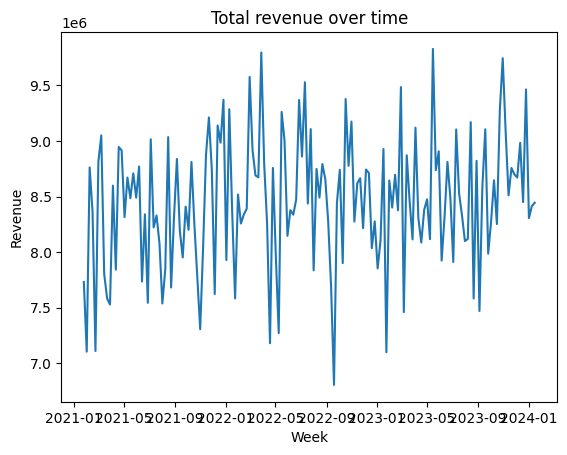

In [179]:
plt.figure()
plt.plot(weekly["week"], weekly["revenue"])
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.title("Total revenue over time")
plt.show()

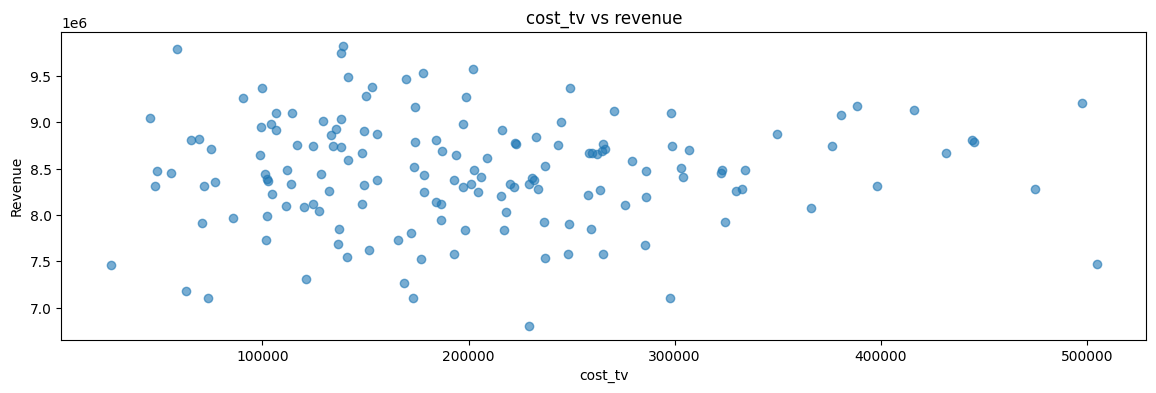

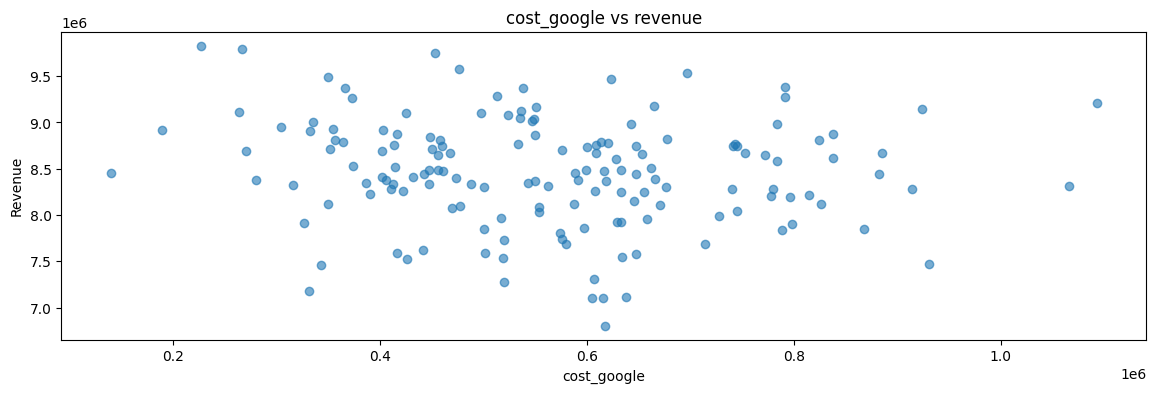

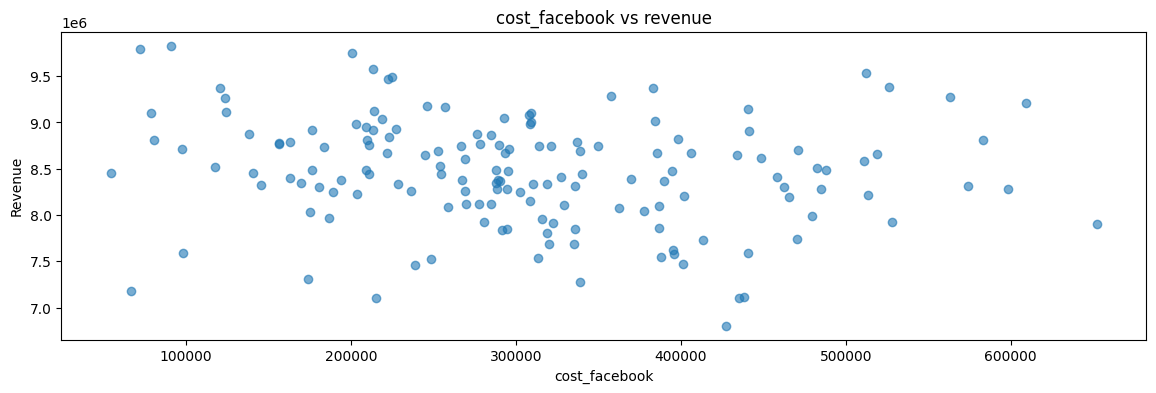

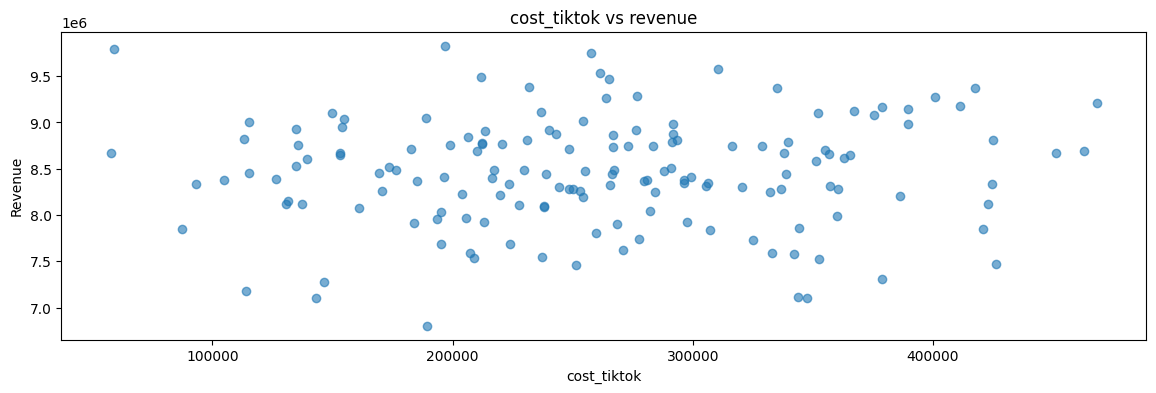

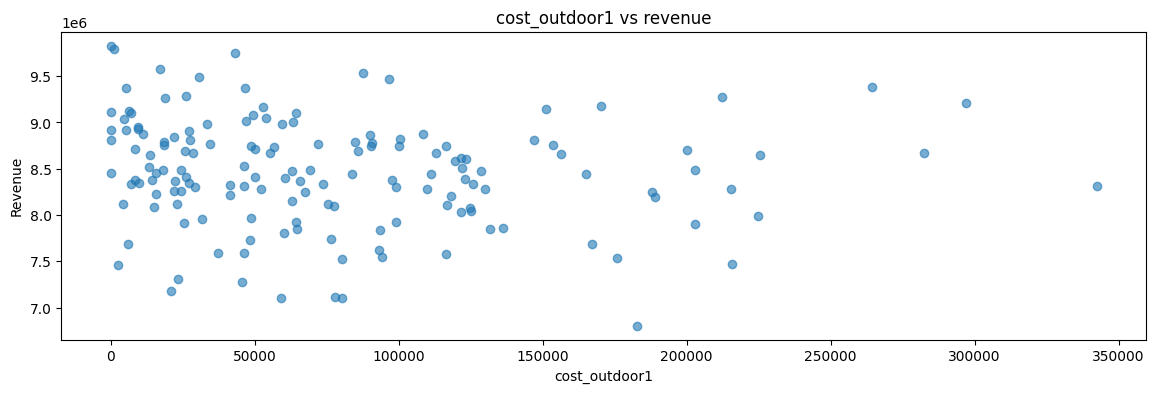

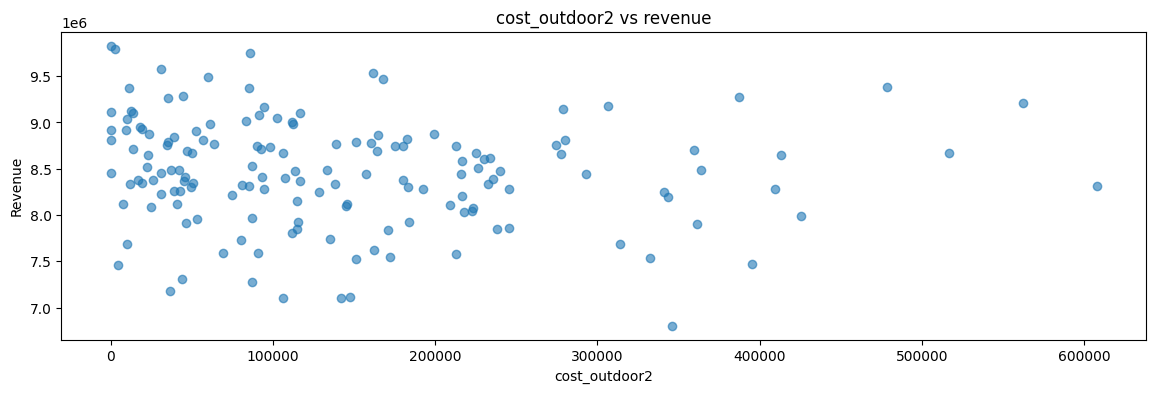

In [177]:
channels = {
    "TV": "cost_tv",
    "Google Ads": "cost_google",
    "Facebook Ads": "cost_facebook",
    "TikTok Ads": "cost_tiktok",
    "Outdoor 1": "cost_outdoor1",
    "Outdoor 2": "cost_outdoor2",
}

for channel, cost_col in channels.items():
    plt.figure(figsize=(14, 4))

    plt.scatter(weekly[cost_col], weekly["revenue"], alpha=0.6)
    plt.xlabel(cost_col)
    plt.ylabel("Revenue")
    plt.title(f"{cost_col} vs revenue")
    plt.show()

    # plt.plot(
    #     weekly["week"],
    #     weekly["revenue"]/10,
    #     label="Revenue",
    #     linewidth=3
    # )

    # plt.plot(
    #     weekly["week"],
    #     weekly[cost_col],
    #     label=f"{channel} cost",
    #     linewidth=2
    # )

    # plt.title(f"Revenue vs {channel} cost (weekly)")
    # plt.xlabel("Week")
    # plt.ylabel("Value")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()

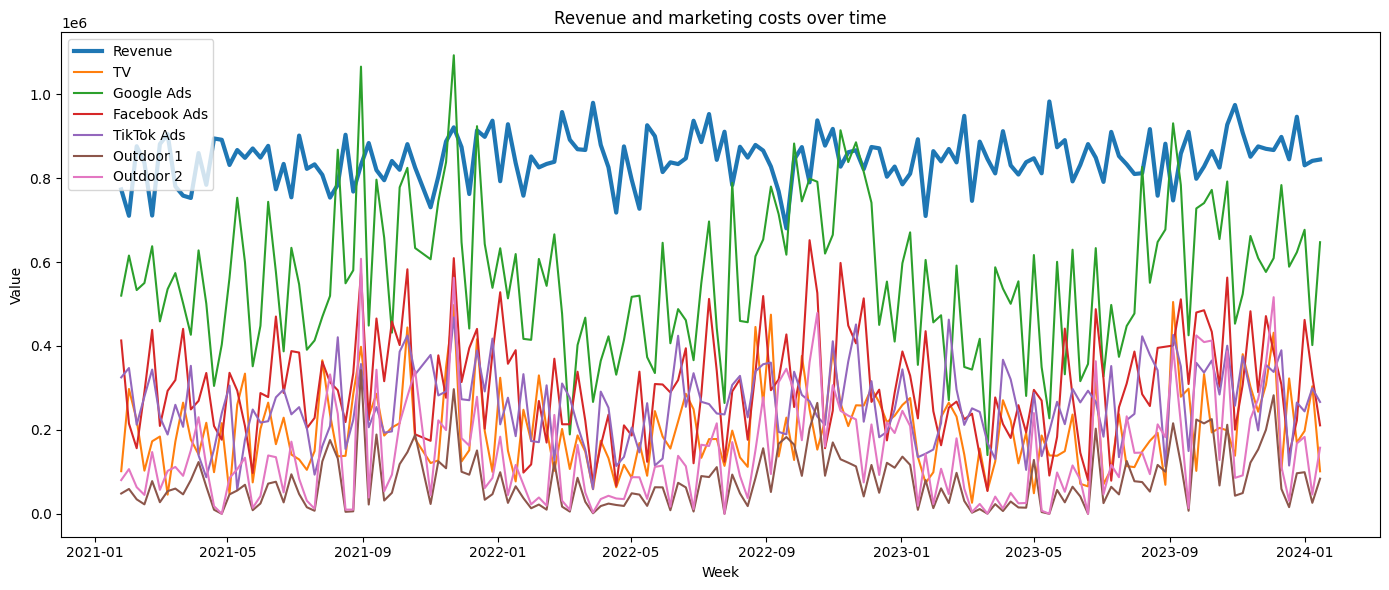

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(weekly["week"], weekly["revenue"]/10, label="Revenue", linewidth=3)

plt.plot(weekly["week"], weekly["cost_tv"], label="TV")
plt.plot(weekly["week"], weekly["cost_google"], label="Google Ads")
plt.plot(weekly["week"], weekly["cost_facebook"], label="Facebook Ads")
plt.plot(weekly["week"], weekly["cost_tiktok"], label="TikTok Ads")
plt.plot(weekly["week"], weekly["cost_outdoor1"], label="Outdoor 1")
plt.plot(weekly["week"], weekly["cost_outdoor2"], label="Outdoor 2")

plt.xlabel("Week")
plt.ylabel("Value")
plt.title("Revenue and marketing costs over time")
plt.legend()
plt.tight_layout()
plt.show()


In [182]:
corr_cols = [
    "revenue",
    "conversions",
    "cost_tv",
    "cost_google",
    "cost_facebook",
    "cost_tiktok",
    "cost_outdoor1",
    "cost_outdoor2",
    "promo"
]

weekly[corr_cols].corr()["revenue"].sort_values(ascending=False)


,revenue
revenue,1.000000
conversions,0.999924
promo,0.263049
cost_tiktok,0.048281
cost_tv,0.014280
cost_outdoor2,-0.114033
cost_outdoor1,-0.115081
cost_google,-0.124931
cost_facebook,-0.174199


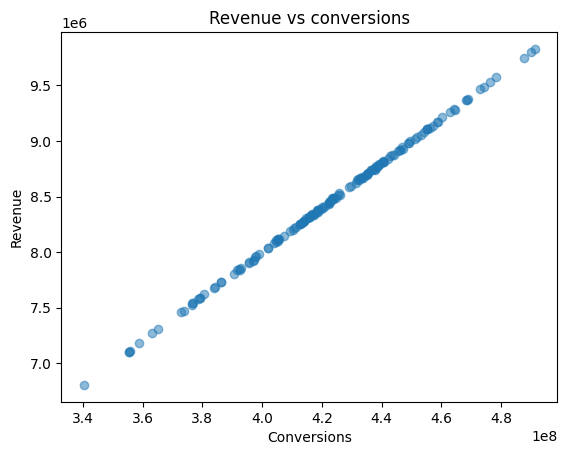

In [185]:
plt.figure()
plt.scatter(weekly["conversions"], weekly["revenue"], alpha=0.5)
plt.xlabel("Conversions")
plt.ylabel("Revenue")
plt.title("Revenue vs conversions")
plt.show()

conversions i revenue są bardzo skorelowane, dlatego conversions należy usunąć przed modelowaniem!

In [184]:
weekly["is_promo"] = weekly["promo"] > 0

weekly.groupby("is_promo")["revenue"].describe()


,count,mean,std,min,25%,50%,75%,max
is_promo,,,,,,,,
True,155.0,8.456447e+06,584439.059372,6.805080e+06,8.115494e+06,8.457473e+06,8.813237e+06,9.828881e+06
